<a href="https://colab.research.google.com/github/CARLOSM419/Practica2_Modelos-de-aprendizaje-automatico/blob/main/Practica2_MAA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dimensiones de X: (442, 10)
Dimensiones de y: (442,)
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null   

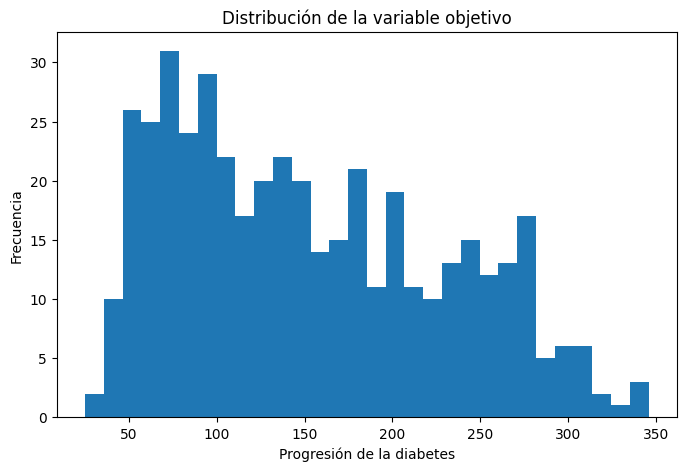

Regresión lineal
MAE: 42.79409467959994
RMSE: 53.853445836765935
R² : 0.45260276297191926
  Variable  Coeficiente
4       s1   -44.448856
8       s5    35.161195
2      bmi    25.607121
5       s2    24.640954
3       bp    16.828872
7       s4    13.138784
1      sex   -11.511809
6       s3     7.676978
9       s6     2.351364
0      age     1.753758

Ridge - L2
MAE: 42.81199941834888
RMSE: 53.777454065343896
R² : 0.45414652070698225
  Variable  Coeficiente
0      age     1.807342
1      sex   -11.448190
2      bmi    25.732699
3       bp    16.734300
4       s1   -34.671954
5       s2    17.053075
6       s3     3.369914
7       s4    11.764260
8       s5    31.378384
9       s6     2.458139

Lasso - L1
MAE: 42.805234446768836
RMSE: 53.70869844573793
R² : 0.45554139902790414

--- Comparación de Modelos ---
             Modelo        MAE       RMSE        R2
0  Regresión lineal  42.794095  53.853446  0.452603
1          Ridge L2  42.811999  53.777454  0.454147
2          Lasso L1  42.

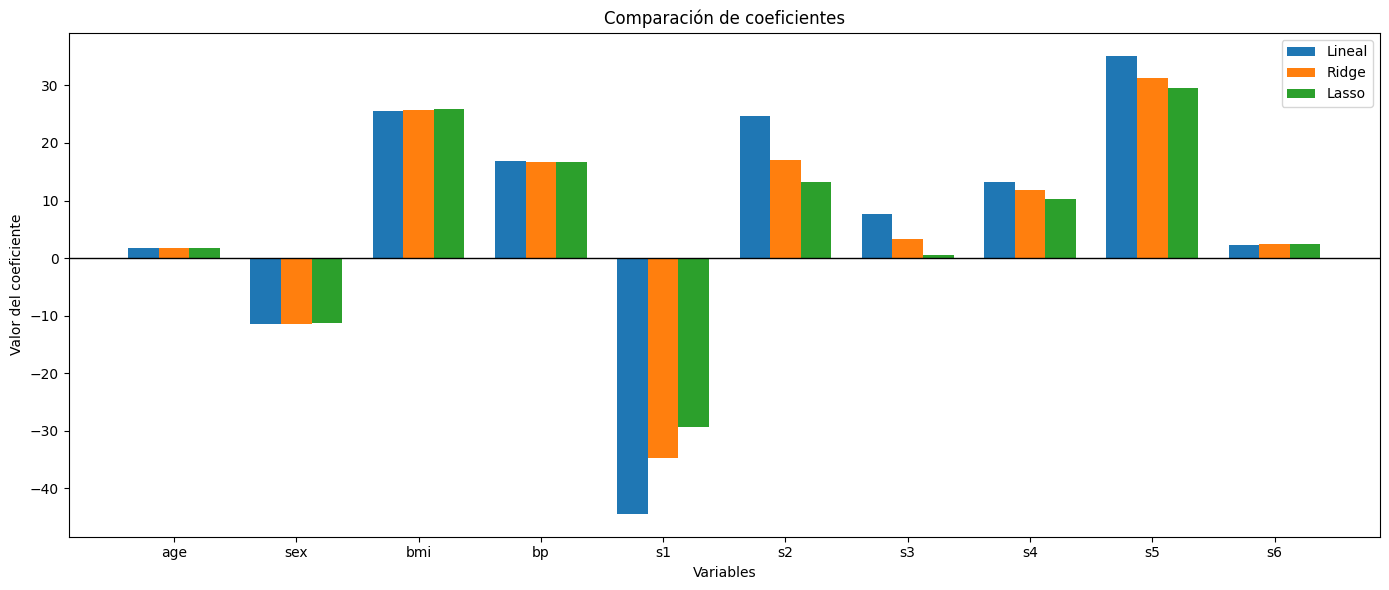

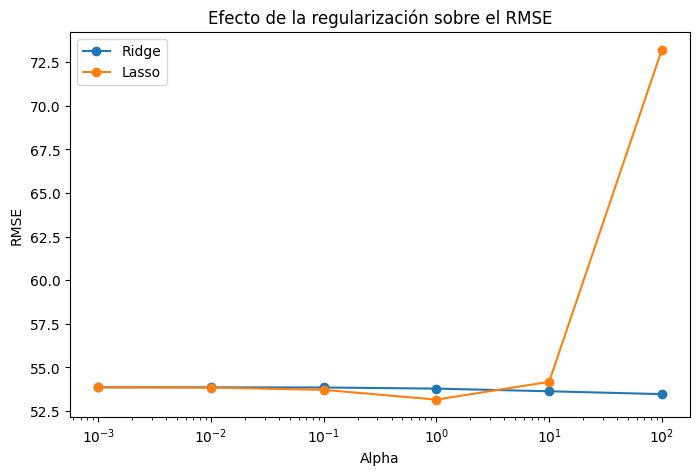

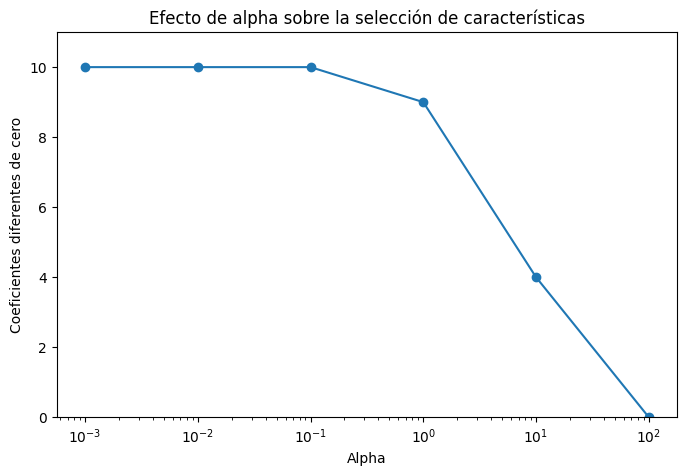


--- Tabla de Resultados del Reto ---
    Alpha  RMSE Ridge  R² Ridge  RMSE Lasso  R² Lasso  Coeficientes Lasso != 0
   0.0001   53.853435  0.452603   53.853274  0.452606                       10
   0.0010   53.853335  0.452605   53.851726  0.452638                       10
   0.0100   53.852346  0.452625   53.836493  0.452947                       10
   0.1000   53.842869  0.452818   53.708698  0.455541                       10
   1.0000   53.777454  0.454147   53.146666  0.466877                        9
  10.0000   53.626288  0.457211   54.164885  0.446253                        4
 100.0000   53.462363  0.460524   73.222493 -0.011963                        0
1000.0000   58.751267  0.348507   73.222493 -0.011963                        0


In [1]:
# ==========================================================
# PRÁCTICA 2. REGULARIZACIÓN L1 Y L2
# ==========================================================

# ----------------------------------------------------------
# 6.1 Importación de librerías
# ----------------------------------------------------------
# Importa NumPy para realizar operaciones numéricas.
import numpy as np

# Importa Pandas para trabajar con tablas y estructuras de datos.
import pandas as pd

# Importa Matplotlib para generar visualizaciones.
import matplotlib.pyplot as plt

# Importa la función que proporciona el conjunto de datos Diabetes.
from sklearn.datasets import load_diabetes

# ----------------------------------------------------------
# 6.2 Carga del conjunto de datos
# ----------------------------------------------------------
# Carga el conjunto de datos Diabetes.
data = load_diabetes()

# Obtiene las variables predictoras.
X = data.data

# Obtiene la variable que representa la progresión de la diabetes.
y = data.target

# Muestra el número de observaciones y variables.
print("Dimensiones de X:", X.shape)

# Muestra el número de valores objetivo.
print("Dimensiones de y:", y.shape)

# ----------------------------------------------------------
# 6.3 Construcción del DataFrame
# ----------------------------------------------------------
# Crea un DataFrame utilizando las características del conjunto de datos.
df = pd.DataFrame(X, columns=data.feature_names)

# Agrega la variable objetivo como una nueva columna.
df["target"] = y

# Muestra los primeros cinco registros.
print(df.head())

# ----------------------------------------------------------
# 6.4 Exploración de los datos
# ----------------------------------------------------------
# Muestra información sobre las columnas y tipos de datos.
df.info()

# Calcula estadísticas descriptivas de las variables.
print(df.describe())

# Cuenta los valores faltantes de cada columna.
print(df.isnull().sum())

# ----------------------------------------------------------
# 6.5 Visualización de la variable objetivo
# ----------------------------------------------------------
# Define el tamaño de la figura.
plt.figure(figsize=(8, 5))

# Genera un histograma de la variable objetivo.
plt.hist(y, bins=30)

# Define el nombre del eje X.
plt.xlabel("Progresión de la diabetes")

# Define el nombre del eje Y.
plt.ylabel("Frecuencia")

# Agrega un título.
plt.title("Distribución de la variable objetivo")

# Muestra la gráfica.
plt.show()

# ----------------------------------------------------------
# 6.6 División de los datos
# ----------------------------------------------------------
# Importa la función para dividir los datos.
from sklearn.model_selection import train_test_split

# Divide los datos en entrenamiento y prueba.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------------------------------------
# 6.7 Estandarización de las variables
# ----------------------------------------------------------
# Importa StandardScaler para estandarizar las variables.
from sklearn.preprocessing import StandardScaler

# Crea un objeto encargado de realizar la estandarización.
scaler = StandardScaler()

# Calcula media y desviación estándar utilizando los datos de entrenamiento
# y transforma posteriormente esos datos.
X_train_scaled = scaler.fit_transform(X_train)

# Utiliza la misma transformación calculada con los datos de entrenamiento.
X_test_scaled = scaler.transform(X_test)

# ----------------------------------------------------------
# 6.8 Modelo base: regresión lineal
# ----------------------------------------------------------
# Importa el modelo de regresión lineal.
from sklearn.linear_model import LinearRegression

# Crea una instancia de regresión lineal sin regularización.
modelo_lineal = LinearRegression()

# Entrena el modelo utilizando los datos estandarizados.
modelo_lineal.fit(X_train_scaled, y_train)

# Genera predicciones para los datos de prueba.
pred_lineal = modelo_lineal.predict(X_test_scaled)

# ----------------------------------------------------------
# 6.9 Evaluación del modelo base
# ----------------------------------------------------------
# Importa métricas para evaluar modelos de regresión.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calcula el error absoluto medio.
mae_lineal = mean_absolute_error(y_test, pred_lineal)

# Calcula el error cuadrático medio.
rmse_lineal = np.sqrt(mean_squared_error(y_test, pred_lineal))

# Calcula el coeficiente de determinación.
r2_lineal = r2_score(y_test, pred_lineal)

# Muestra las métricas obtenidas por la regresión lineal.
print("Regresión lineal")
print("MAE:", mae_lineal)
print("RMSE:", rmse_lineal)
print("R² :", r2_lineal)

# ----------------------------------------------------------
# 6.10 Análisis de los coeficientes del modelo lineal
# ----------------------------------------------------------
# Crea una tabla con el nombre de cada variable y su coeficiente.
coef_lineal = pd.DataFrame(
    {"Variable": data.feature_names, "Coeficiente": modelo_lineal.coef_}
)

# Muestra la tabla ordenada por el valor absoluto del coeficiente.
print(
    coef_lineal.reindex(
        coef_lineal["Coeficiente"].abs().sort_values(ascending=False).index
    )
)

# ----------------------------------------------------------
# 6.11 Modelo Ridge - Regularización L2
# ----------------------------------------------------------
# Importa el algoritmo Ridge, que utiliza regularización L2.
from sklearn.linear_model import Ridge

# Crea un modelo Ridge con alpha igual a 1.
modelo_ridge = Ridge(alpha=1.0)

# Entrena el modelo Ridge con los datos de entrenamiento.
modelo_ridge.fit(X_train_scaled, y_train)

# Genera predicciones para el conjunto de prueba.
pred_ridge = modelo_ridge.predict(X_test_scaled)

# ----------------------------------------------------------
# 6.12 Evaluación de Ridge
# ----------------------------------------------------------
# Calcula el MAE del modelo Ridge.
mae_ridge = mean_absolute_error(y_test, pred_ridge)

# Calcula el RMSE del modelo Ridge.
rmse_ridge = np.sqrt(mean_squared_error(y_test, pred_ridge))

# Calcula el R² del modelo Ridge.
r2_ridge = r2_score(y_test, pred_ridge)

# Muestra las métricas del modelo Ridge.
print("\nRidge - L2")
print("MAE:", mae_ridge)
print("RMSE:", rmse_ridge)
print("R² :", r2_ridge)

# ----------------------------------------------------------
# 6.13 Análisis de los coeficientes Ridge
# ----------------------------------------------------------
# Crea una tabla para comparar los coeficientes de Ridge.
coef_ridge = pd.DataFrame(
    {"Variable": data.feature_names, "Coeficiente": modelo_ridge.coef_}
)

# Muestra los coeficientes.
print(coef_ridge)

# ----------------------------------------------------------
# 6.14 Modelo Lasso - Regularización L1
# ----------------------------------------------------------
# Importa el algoritmo Lasso, que utiliza regularización L1.
from sklearn.linear_model import Lasso

# Crea un modelo Lasso con alpha igual a 0.1.
modelo_lasso = Lasso(alpha=0.1)

# Entrena el modelo Lasso.
modelo_lasso.fit(X_train_scaled, y_train)

# Genera predicciones sobre los datos de prueba.
pred_lasso = modelo_lasso.predict(X_test_scaled)

# ----------------------------------------------------------
# 6.15 Evaluación de Lasso
# ----------------------------------------------------------
# Calcula el MAE del modelo Lasso.
mae_lasso = mean_absolute_error(y_test, pred_lasso)

# Calcula el RMSE del modelo Lasso.
rmse_lasso = np.sqrt(mean_squared_error(y_test, pred_lasso))

# Calcula el R² del modelo Lasso.
r2_lasso = r2_score(y_test, pred_lasso)

# Muestra las métricas obtenidas por Lasso.
print("\nLasso - L1")
print("MAE:", mae_lasso)
print("RMSE:", rmse_lasso)
print("R² :", r2_lasso)

# ----------------------------------------------------------
# 6.16 Comparación de los tres modelos
# ----------------------------------------------------------
# Crea una tabla para comparar los tres modelos.
resultados = pd.DataFrame(
    {
        "Modelo": ["Regresión lineal", "Ridge L2", "Lasso L1"],
        "MAE": [mae_lineal, mae_ridge, mae_lasso],
        "RMSE": [rmse_lineal, rmse_ridge, rmse_lasso],
        "R2": [r2_lineal, r2_ridge, r2_lasso],
    }
)

# Muestra la tabla de resultados.
print("\n--- Comparación de Modelos ---")
print(resultados)

# ----------------------------------------------------------
# 6.17 Comparación de coeficientes
# ----------------------------------------------------------
# Construye una tabla con los coeficientes de los tres modelos.
coeficientes = pd.DataFrame(
    {
        "Variable": data.feature_names,
        "Lineal": modelo_lineal.coef_,
        "Ridge": modelo_ridge.coef_,
        "Lasso": modelo_lasso.coef_,
    }
)

# Muestra la tabla.
print("\n--- Comparación de Coeficientes ---")
print(coeficientes)

# ----------------------------------------------------------
# 6.18 Identificación de coeficientes eliminados por Lasso
# ----------------------------------------------------------
# Identifica qué coeficientes de Lasso son exactamente iguales a cero.
coef_cero = np.isclose(modelo_lasso.coef_, 0)

# Muestra los nombres de las variables cuyos coeficientes fueron eliminados.
print(
    "\nVariables eliminadas por Lasso:",
    np.array(data.feature_names)[coef_cero],
)

# ----------------------------------------------------------
# 6.19 Visualización de los coeficientes
# ----------------------------------------------------------
# Define la posición de cada variable en el eje X.
posiciones = np.arange(len(data.feature_names))

# Define el ancho de cada grupo de barras.
ancho = 0.25

# Crea una figura.
plt.figure(figsize=(14, 6))

# Dibuja los coeficientes del modelo lineal.
plt.bar(
    posiciones - ancho,
    modelo_lineal.coef_,
    width=ancho,
    label="Lineal",
)

# Dibuja los coeficientes de Ridge.
plt.bar(posiciones, modelo_ridge.coef_, width=ancho, label="Ridge")

# Dibuja los coeficientes de Lasso.
plt.bar(
    posiciones + ancho,
    modelo_lasso.coef_,
    width=ancho,
    label="Lasso",
)

# Coloca los nombres de las variables en el eje X.
plt.xticks(posiciones, data.feature_names)

# Agrega una línea horizontal correspondiente a cero.
plt.axhline(0, color="black", linewidth=1)

# Etiqueta el eje X.
plt.xlabel("Variables")

# Etiqueta el eje Y.
plt.ylabel("Valor del coeficiente")

# Agrega un título.
plt.title("Comparación de coeficientes")

# Muestra la leyenda.
plt.legend()

# Ajusta automáticamente los elementos de la gráfica.
plt.tight_layout()

# Muestra la gráfica.
plt.show()

# ----------------------------------------------------------
# 6.20 Experimentación con diferentes valores de alpha
# ----------------------------------------------------------
# Define diferentes intensidades de regularización.
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

# Crea listas vacías para almacenar resultados.
rmse_ridge_lista = []
rmse_lasso_lista = []
coeficientes_lasso = []

# Recorre todos los valores de alpha.
for alpha in alphas:
    # Crea un nuevo modelo Ridge utilizando el alpha actual.
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    pred_ridge = ridge.predict(X_test_scaled)
    rmse_ridge_lista.append(np.sqrt(mean_squared_error(y_test, pred_ridge)))

    # Crea un nuevo modelo Lasso.
    lasso = Lasso(alpha=alpha, max_iter=1000)
    lasso.fit(X_train_scaled, y_train)
    pred_lasso = lasso.predict(X_test_scaled)
    rmse_lasso_lista.append(np.sqrt(mean_squared_error(y_test, pred_lasso)))

    # Cuenta cuántos coeficientes de Lasso son diferentes de cero.
    cantidad = np.sum(np.abs(lasso.coef_) > 1e-6)
    coeficientes_lasso.append(cantidad)

# ----------------------------------------------------------
# 6.21 Visualización del efecto de alpha
# ----------------------------------------------------------
plt.figure(figsize=(8, 5))

# Grafica el RMSE de Ridge.
plt.semilogx(alphas, rmse_ridge_lista, marker="o", label="Ridge")

# Grafica el RMSE de Lasso.
plt.semilogx(alphas, rmse_lasso_lista, marker="o", label="Lasso")

plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.title("Efecto de la regularización sobre el RMSE")
plt.legend()
plt.show()

# ----------------------------------------------------------
# 6.22 Efecto de L1 sobre la cantidad de características
# ----------------------------------------------------------
plt.figure(figsize=(8, 5))

# Grafica el número de coeficientes activos para cada alpha.
plt.semilogx(alphas, coeficientes_lasso, marker="o")

plt.xlabel("Alpha")
plt.ylabel("Coeficientes diferentes de cero")
plt.title("Efecto de alpha sobre la selección de características")
plt.ylim(0, len(data.feature_names) + 1)
plt.show()

# ==========================================================
# 7. RETO: SELECCIÓN DEL MEJOR MODELO Y VALOR DE ALPHA
# ==========================================================
# Parte 1. Pruebe más valores de alpha
alphas_reto = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]

tabla_reto = []

for alpha in alphas_reto:
    # Ridge
    r_model = Ridge(alpha=alpha)
    r_model.fit(X_train_scaled, y_train)
    r_pred = r_model.predict(X_test_scaled)
    r_rmse = np.sqrt(mean_squared_error(y_test, r_pred))
    r_r2 = r2_score(y_test, r_pred)

    # Lasso
    l_model = Lasso(alpha=alpha, max_iter=10000)
    l_model.fit(X_train_scaled, y_train)
    l_pred = l_model.predict(X_test_scaled)
    l_rmse = np.sqrt(mean_squared_error(y_test, l_pred))
    l_r2 = r2_score(y_test, l_pred)
    l_non_zero = np.sum(np.abs(l_model.coef_) > 1e-6)

    tabla_reto.append(
        {
            "Alpha": alpha,
            "RMSE Ridge": r_rmse,
            "R² Ridge": r_r2,
            "RMSE Lasso": l_rmse,
            "R² Lasso": l_r2,
            "Coeficientes Lasso != 0": l_non_zero,
        }
    )

# Muestra la tabla del Reto
df_reto = pd.DataFrame(tabla_reto)
print("\n--- Tabla de Resultados del Reto ---")
print(df_reto.to_string(index=False))